# Trabalho individual II

UC: Optimização Heurística


Discentre: Camila Tavares de Sousa


Numero de aluno: 111017


Turma: CDB1

## Problema 

Objetivo Principal:
    
            Maximizar a rentabilidade esperada das zonas escolhidas

Restrições:
            
            A soma dos índices de impacto ambiental das quatro zonas não pode exceder 8. 
           
            As zonas escolhidas não podem ser adjacentes

## Representação dos Dados 

Utilizae um DataFrame para organizar as informações sobre as zonas, incluindo a rentabilidade esperada e o impacto ambiental 

In [1]:
import pandas as pd
from itertools import combinations

data = {
    "Zona": ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9", "A10",
             "A11", "A12", "A13", "A14", "A15", "A16", "A17", "A18", "A19", "A20",
             "A21", "A22", "A23", "A24", "A25", "A26", "A27", "A28", "A29", "A30"],
    "Rentabilidade Esperada": [2600, 3400, 1900, 2100, 3000, 3200, 3400, 4300, 4700, 1100,
                               4600, 4700, 1700, 5000, 1900, 2900, 1300, 3300, 3000, 4200,
                               4200, 2400, 4600, 1800, 4500, 2000, 1700, 1700, 1500, 1700],
    "Impacto Ambiental": [2, 4, 3, 4, 2, 2, 1, 2, 4, 3, 4, 4, 1, 4, 1, 1, 4, 1, 1, 1,
                          4, 1, 3, 1, 4, 2, 1, 3, 2, 3]
}

df = pd.DataFrame(data)

print(df)


   Zona  Rentabilidade Esperada  Impacto Ambiental
0    A1                    2600                  2
1    A2                    3400                  4
2    A3                    1900                  3
3    A4                    2100                  4
4    A5                    3000                  2
5    A6                    3200                  2
6    A7                    3400                  1
7    A8                    4300                  2
8    A9                    4700                  4
9   A10                    1100                  3
10  A11                    4600                  4
11  A12                    4700                  4
12  A13                    1700                  1
13  A14                    5000                  4
14  A15                    1900                  1
15  A16                    2900                  1
16  A17                    1300                  4
17  A18                    3300                  1
18  A19                    3000

## Adjacencias dos terrenos

In [2]:
adjacencias = {
    "A1": ["A7", "A2"],
    "A2": ["A1", "A3", "A4", "A8"],
    "A3": ["A2", "A4", "A5"],
    "A4": ["A2", "A3", "A5","A9","A10"],
    "A5": ["A3", "A4", "A11", "A6"],
    "A6": ["A5","A12"],
    "A7": ["A1", "A8", "A13"],
    "A8": ["A2", "A7", "A9", "A13", "A14"],
    "A9": ["A8", "A4", "A10", "A14", "A15"],
    "A10": ["A4", "A9", "A15", "A11"],
    "A11": ["A5", "A10", "A12", "A16"],
    "A12": ["A6", "A11", "A17"],
    "A13": ["A7", "A8", "A14", "A18"],
    "A14": ["A8", "A9", "A13", "A15", "A19"],
    "A15": ["A9", "A10", "A14", "A16", "A21"],
    "A16": ["A11", "A15", "A17", "A23"],
    "A17": ["A12", "A16", "A25"],
    "A18": ["A13", "A19", "A20", "A26"],
    "A19": ["A14", "A18", "A20", "A21"],
    "A20": ["A19", "A18", "A22", "A27"],
    "A21": ["A15", "A19", "A22", "A23"],
    "A22": ["A20", "A21", "A24", "A28"],
    "A23": ["A16", "A21", "A24", "A25"],
    "A24": ["A23", "A22", "A25", "A29"],
    "A25": ["A17", "A23", "A24","A30"],
    "A26": ["A18", "A27"],
    "A27": ["A20", "A26", "A28"],
    "A28": ["A22", "A27", "A29"],
    "A29": ["A24", "A28", "A30"],
    "A30": ["A29", "A25"],
}

# Heurística

### Ordenar Zonas
Ordenar com base na rentabilidade por unidade de impacto, em ordem decrescente

In [3]:
df["Rentabilidade por Impacto"] = df["Rentabilidade Esperada"] / df["Impacto Ambiental"]

from tabulate import tabulate
df = df.sort_values(by="Rentabilidade por Impacto", ascending=False)
table = tabulate(df, headers='keys', tablefmt='grid', showindex=False)
print(table)

+--------+--------------------------+---------------------+-----------------------------+
| Zona   |   Rentabilidade Esperada |   Impacto Ambiental |   Rentabilidade por Impacto |
+========+==========================+=====================+=============================+
| A20    |                     4200 |                   1 |                    4200     |
+--------+--------------------------+---------------------+-----------------------------+
| A7     |                     3400 |                   1 |                    3400     |
+--------+--------------------------+---------------------+-----------------------------+
| A18    |                     3300 |                   1 |                    3300     |
+--------+--------------------------+---------------------+-----------------------------+
| A19    |                     3000 |                   1 |                    3000     |
+--------+--------------------------+---------------------+-----------------------------+
| A16    |

### Seleção das Zonas 
Implementação heurística construtiva para selecionar as zonas: 


Percorrer a lista de zonas ordenadas e selecione aquelas que atendem às restrições

Para cada zona selecionada, verificar se é adjacente a qualquer zona já selecionada       
Confirmar se a soma dos índices de impacto ambiental das zonas selecionadas não ultrapasse 8

In [4]:
# Função para verificar se duas zonas são adjacentes
def sao_adjacentes(zona1, zona2):
    return zona2 in adjacencias.get(zona1, [])

# Seleção de zonas usando a heurística
selecionadas = []
impacto_total = 0

for idx, row in df.iterrows():
    zona = row["Zona"]
    impacto = row["Impacto Ambiental"]

    # Verificar se a zona é adjacente a qualquer uma das zonas já selecionadas
    adjacente = any(sao_adjacentes(zona, s) for s in selecionadas)
    
    if not adjacente and (impacto_total + impacto <= 8):
        selecionadas.append(zona)
        impacto_total += impacto
    
    # Parar se já tiver sido selecionadas quatro zonas
    if len(selecionadas) == 4 or impacto_total == 8:
        break

# Resultado
print("Zonas selecionadas:", selecionadas)


Zonas selecionadas: ['A20', 'A7', 'A16', 'A24']


### Avaliação da Solução

Calcular a rentabilidade total das zonas selecionadas


Calcular o impacto ambiental total

In [5]:
rentabilidade_total = df[df["Zona"].isin(selecionadas)]["Rentabilidade Esperada"].sum()
print(f"Rentabilidade Total: {rentabilidade_total}")
print(f"Impacto Total: {impacto_total}")

Rentabilidade Total: 12300
Impacto Total: 4


In [6]:
print(df)

   Zona  Rentabilidade Esperada  Impacto Ambiental  Rentabilidade por Impacto
19  A20                    4200                  1                4200.000000
6    A7                    3400                  1                3400.000000
17  A18                    3300                  1                3300.000000
18  A19                    3000                  1                3000.000000
15  A16                    2900                  1                2900.000000
21  A22                    2400                  1                2400.000000
7    A8                    4300                  2                2150.000000
14  A15                    1900                  1                1900.000000
23  A24                    1800                  1                1800.000000
26  A27                    1700                  1                1700.000000
12  A13                    1700                  1                1700.000000
5    A6                    3200                  2              

# Vizinhança

A partir da solução geranda anteriormente, gerar uma solução vizinha substituindo uma das zonas
A zona a substituir é a A24 por apresentar menor rendimento. Pretende-se com esta solução vizinha fazer um trade-off entre impacto ambiental e rentabilidade, e por isso substituir-se-á por uma zona de impacto 4 com rendimento maior.

In [7]:
zonas_selecionadas = ['A20', 'A7', 'A16']
# Criar uma função que verifique se uma zona é adjacente às zonas selecionadas
def nao_adjacente_a_selecionadas(zona, selecionadas):
    for selecionada in selecionadas:
        if selecionada in adjacencias.get(zona, []):
            return False
    return True

#Selecionar as zonas não adjacentes/zonas disponíveis que têm impacto 4
zonas_nao_adjacentes = [
    zona for zona in df[df["Impacto Ambiental"] == 4]["Zona"]
    if nao_adjacente_a_selecionadas(zona, zonas_selecionadas)
]

print("Zonas não adjacentes às zonas selecionadas e que têm impacto 4:", zonas_nao_adjacentes)

Zonas não adjacentes às zonas selecionadas e que têm impacto 4: ['A14', 'A12', 'A9', 'A25', 'A21', 'A2', 'A4']


# Simulated Annealing

In [56]:
import random
import numpy as np
import math

#Função que devolve o impacto total de uma solução
def impacto_total(solucao):
    impacto_total = 0
    for zona in solucao:
        impacto_total += df[df["Zona"] == zona]["Impacto Ambiental"].values[0]
    return impacto_total

#Função que verifica se as zonas de uma solução são adjacentes entre si
def adjacentes(solucao):
    for i in range(len(solucao)):
        for j in range(i + 1, len(solucao)):
            if sao_adjacentes(solucao[i], solucao[j]):
                return True
    return False

#Função que gera uma solução inicial aleatória. Nota: poderia se usar uma das duas soluções anteriormente obtidas
def gerar_solucao_inicial():
    while True:
        solucao = random.sample(list(df["Zona"]), 4)
        if (impacto_total(solucao) <= 8) and (not adjacentes(solucao)):
            return solucao

#Função que devovle uma lista de zonas disponíveis. vai ser usada para calcular soluções vizinhas            
def obter_zonas_disponiveis(solucao_atual):
    zonas_adjacentes = set() #set para nao permitir zonas duplicadas
    zonas_disponiveis = set(df["Zona"].tolist()) #iniciar com todas as zonas da lista
    
    #Para cada zona adicionar as adjacencias a zonas_adjacentes, para retirar das zonas disponíveis
    for zona_atual in solucao_atual:
        adjacencias_zona_atual = adjacencias[zona_atual]
        zonas_adjacentes.update(adjacencias_zona_atual)
        zonas_disponiveis.remove(zona_atual) #remover as zonas já na solução das zonas disponíveis
    
    # Remover as zonas adjacentes do conjunto de zonas disponíveis
    zonas_disponiveis.difference_update(zonas_adjacentes)

    return list(zonas_disponiveis)

#Função que devolve uma solução vizinha substituindo uma das 4 zonas
def vizinho(solucao_atual):
    tentativa = 0
    while tentativa < 100:
        nova_solucao = solucao_atual.copy()
        zona_removida = random.choice(solucao_atual) #Escolher uma zona aleatória da solução
        nova_solucao.remove(zona_removida)# Remover uma zona aleatória da solução
        zonas_disponiveis = obter_zonas_disponiveis(nova_solucao) # Obter as zonas disponíveis para substituição
        # Verificar se há zonas disponíveis
        if not zonas_disponiveis:
            raise ValueError("Nenhuma zona disponível")
        # Escolher uma zona aleatória das zonas disponíveis
        nova_zona = random.choice(zonas_disponiveis)
        nova_solucao_nova_zona = nova_solucao.copy()
        nova_solucao_nova_zona.append(nova_zona)# Adicionar a nova zona à nova solução com zona nova
        if impacto_total(nova_solucao_nova_zona)<=8:#esta nova solução só é válida se o impacto total não exceder 8
            nova_solucao.append(nova_zona)
            return nova_solucao # solução vizinha
        tentativa +=1 # se execeder tenta de novo
    return solucao_atual #após 100 tentativas se não encontrar uma soluçaõ de 4 zonas com impacto total <=8 devolve a solução inicial

#Função objetivo - calcula a rentabilidade de uma solução
def f_obj(solucao):
    rentabilidade_total = df[df["Zona"].isin(solucao)]["Rentabilidade Esperada"].sum()
    return rentabilidade_total

#Função para atualização da temperatura a usar nas iterações do algoritmo SA
def atualizar_temperatura(temperatura_atual):
    alpha = 0.5
    return alpha * temperatura_atual
    
# Como o pretendido é maximizar a função objetivo, então define-se:
#  ∆= 𝑶𝒃𝒋(𝒔𝒐𝒍𝒖çã𝒐 𝒂𝒕𝒖𝒂𝒍) − 𝑶𝒃𝒋(𝒔𝒐𝒍𝒖çã𝒐 𝒗𝒊𝒛𝒊𝒏𝒉𝒂 𝒂𝒍𝒆𝒂𝒕ó𝒓𝒊𝒂 𝒅𝒂 𝒔𝒐𝒍𝒖çã𝒐 𝒂𝒕𝒖𝒂𝒍).
# Regras de aceitação:
#  Se ∆ < 𝟎 então aceitar sempre o movimento (movimento melhorativo);
#  Se ∆ ≥ 𝟎 então aceitar o movimento se 𝑹𝒂𝒏𝒅𝒐𝒎 𝟎, 𝟏 < 𝒆−∆𝑻 (movimento não melhorativo);

def simulated_annealing():
    solucao_atual = gerar_solucao_inicial() # gerar uma solução aleatória que no início é a melhor
    melhor_solucao = solucao_atual
    # definir os parâmetros
    temperatura_inicial = 0.2 * f_obj(solucao_atual)
    temperatura_atual = temperatura_inicial
    
    m = [5] * 5
    n_temperaturas=len(m)

    #criar um dataframe com a informação sobre as iterações
    all_sols = pd.DataFrame(columns=['iter', 'temp', 'zonas', 'rentabilidade', 'impacto_ambiental', 'prob_aceitacao', 'aceite'])
    contador = 0
    
    iterationsk = 0
    
    for k in range(0, n_temperaturas,1):
        for i in range(m[k]):
            nova_solucao = vizinho(solucao_atual)#obter uma solução vizinha
            rentabilidade_ns = f_obj(nova_solucao)#função objetivo de cada nova solução
            impacto_ambiental_ns = impacto_total(nova_solucao)
            
            aceite=False
            prob_aceitacao=1.0
        
            delta = f_obj(solucao_atual) - f_obj(nova_solucao)
            if delta < 0:
                ## A nova solução é melhor do que a atual, portanto o movimento é aceite
                aceite = True
                solucao_atual = nova_solucao #esta solução numa proxima iteração vai ser a de input
            else:
                # Cálculo da probabilidade de aceitação
                prob_aceitacao=np.exp(-delta/temperatura_atual)
                # Gerar de um número pseudo-aleatório com distribuição uniforme U(0,1)
                npa=random.uniform(0.0, 1.0)
                if npa<prob_aceitacao:
                    aceite = True
                    solucao_atual = nova_solucao

            #No fim de cada iteração adicionar uma linha no dataframe com as informações relativas à iteração
            all_sols.loc[contador, :] = {'iter': iterationsk, 'temp': temperatura_atual, 'zonas': nova_solucao, 'rentabilidade': rentabilidade_ns, 'impacto_ambiental': impacto_ambiental_ns, 'prob_aceitacao': prob_aceitacao, 'aceite': aceite}
            contador += 1
            iterationsk += 1

            #se a rentabilidade da solução atual for melhor que a melhor solucao então essa passa a ser a melhor solução
            #calcular os respetivos valores de rentabilidade e imapcacto ambiental total
            if f_obj(solucao_atual) > f_obj(melhor_solucao):
                melhor_solucao = solucao_atual
                rentabilidade_ms = f_obj(melhor_solucao)
                impacto_ambiental_ms = impacto_total(melhor_solucao)
        
        #atualizar a temperatura   
        temperatura_atual = atualizar_temperatura(temperatura_atual)
    
    with open("output_sim_annealing.txt", "w") as f:
        print('Resumo da aplicação do Simulated Annealing:', file=f)
        print(all_sols, file=f)
        print('Melhor solução:', file=f)
        print('zonas:', melhor_solucao, file=f)
        print('rentabilidade', rentabilidade_ms, file=f)
        print('impacto ambiental', impacto_ambiental_ms, file=f)
    
    return melhor_solucao, all_sols

melhor_solucao, all_sols = simulated_annealing()
print("Melhor solução encontrada:", melhor_solucao)
print("Rentabilidade:", f_obj(melhor_solucao))
print("Impacto Ambiental:", impacto_total(melhor_solucao))

Melhor solução encontrada: ['A23', 'A6', 'A19', 'A8']
Rentabilidade: 15100
Impacto Ambiental: 8


## Gráficos

#### Função objetivo

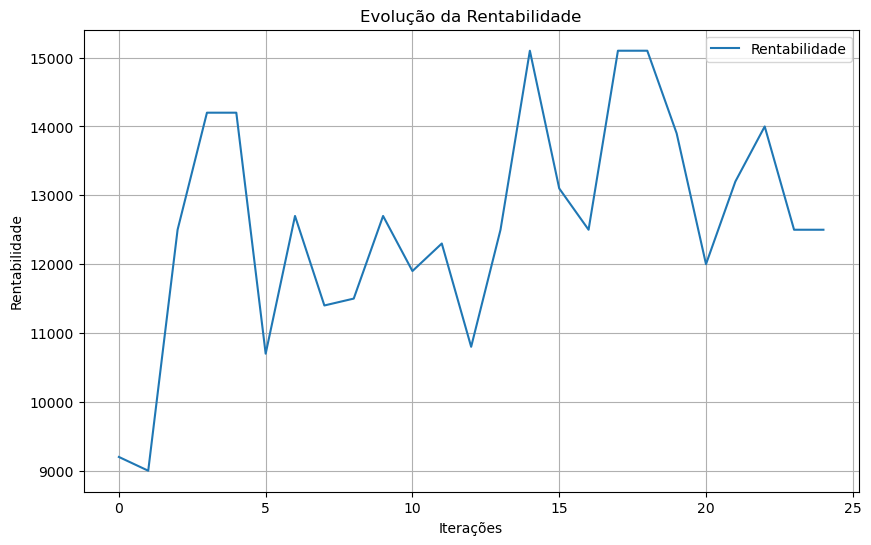

<Figure size 640x480 with 0 Axes>

In [57]:
import matplotlib.pyplot as plt
# Evolução da Função Objetivo
plt.figure(figsize=(10, 6))
plt.plot(all_sols['iter'], all_sols['rentabilidade'], label='Rentabilidade')
plt.xlabel('Iterações')
plt.ylabel('Rentabilidade')
plt.title('Evolução da Rentabilidade')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('books_read.png')

#### Temperatura

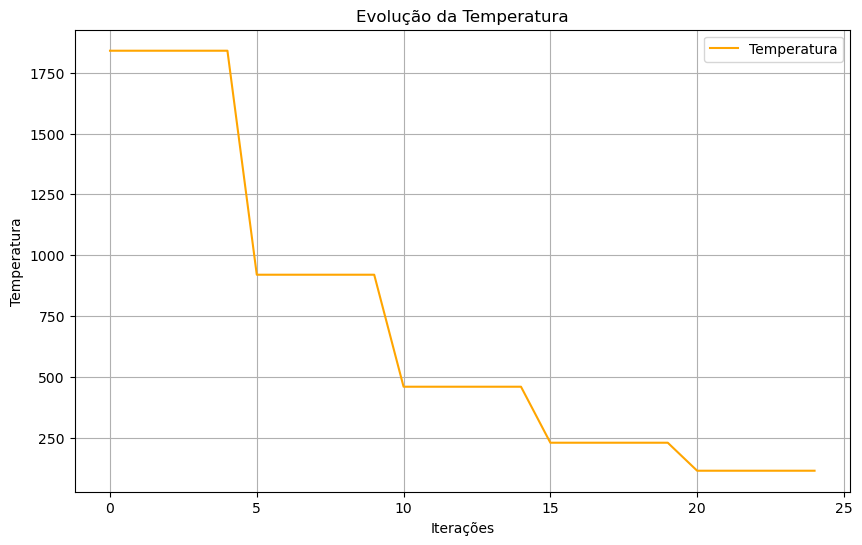

In [58]:
# Evolução da Temperatura
plt.figure(figsize=(10, 6))
plt.plot(all_sols['iter'], all_sols['temp'], label='Temperatura', color='orange')
plt.xlabel('Iterações')
plt.ylabel('Temperatura')
plt.title('Evolução da Temperatura')
plt.legend()
plt.grid(True)
plt.show()

#### Probabilidade de Aceitação

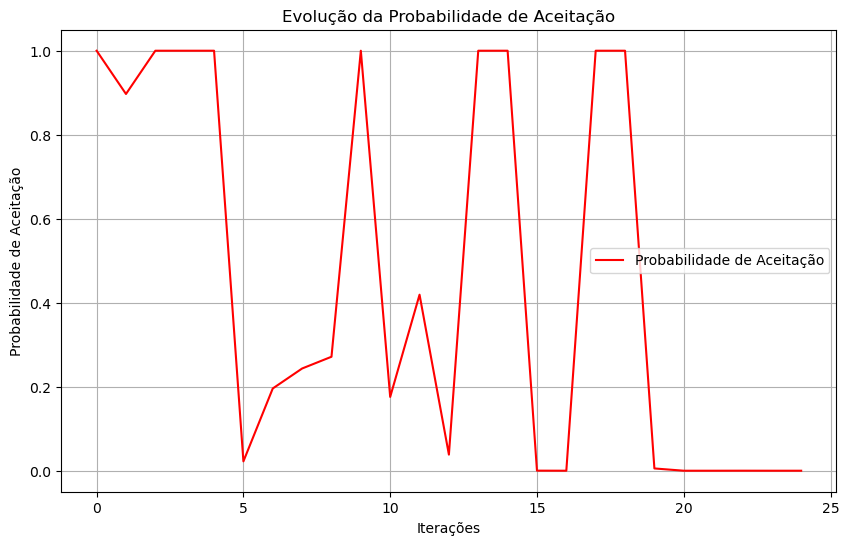

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(all_sols['iter'], all_sols['prob_aceitacao'], label='Probabilidade de Aceitação', color='red')
plt.xlabel('Iterações')
plt.ylabel('Probabilidade de Aceitação')
plt.title('Evolução da Probabilidade de Aceitação')
plt.legend()
plt.grid(True)
plt.show()

## Repetição do código

In [65]:
resultados = []
for _ in range(10):
    melhor_solucao,all_sols = simulated_annealing()
    resultados.append({'Melhor solução encontrada': melhor_solucao,
                       'Rentabilidade': f_obj(melhor_solucao),
                       'Impacto Ambiental': impacto_total(melhor_solucao)})

# Organizar os resultados numa tabela
resultados_df = pd.DataFrame(resultados)

from tabulate import tabulate
table_simulated_anneling = tabulate(resultados_df, headers='keys', tablefmt='grid', showindex=False)
print(table_simulated_anneling)

+-----------------------------+-----------------+---------------------+
| Melhor solução encontrada   |   Rentabilidade |   Impacto Ambiental |
+=============================+=================+=====================+
| ['A5', 'A9', 'A7', 'A18']   |           14400 |                   8 |
+-----------------------------+-----------------+---------------------+
| ['A16', 'A14', 'A7', 'A18'] |           14600 |                   7 |
+-----------------------------+-----------------+---------------------+
| ['A9', 'A6', 'A7', 'A18']   |           14600 |                   8 |
+-----------------------------+-----------------+---------------------+
| ['A16', 'A20', 'A6', 'A8']  |           14600 |                   6 |
+-----------------------------+-----------------+---------------------+
| ['A19', 'A7', 'A12', 'A16'] |           14000 |                   7 |
+-----------------------------+-----------------+---------------------+
| ['A7', 'A20', 'A14', 'A5']  |           15600 |               